# Logistic Regression
- Examination of the coefficients and features.

- Features and References:
    - Log-transformed gross_approval
    - term_in_months split into 6 bins: 61-84mo
    - revolver_status: non-revolver (0)
    - collateral_ind: unsecured (0)
    - naics_sector_description: Construction

- train_test_split will be stratified by y to ensure the default rate matches between train and test groups. 
- One-hot encoding will be employed for naics_sector_description
- log-odds check on training data
- unweighted logit with is_default as a function of the five features
- Compute VIF, with a threshold of 5 to indicate notable overlap
- Create coefficient and odds ratio table
- Run roc_curve and roc_auc_score
- cross_val_score stability check

- Z-scores will be compared to 1.96 and -1.96; any values falling outside of that range would indicate the coefficient has a significant impact on default. A z-score with an absolute value of 1.96 would be comparable to an alpha of 0.05 when testing p-values.

In [1]:
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression # Used for cross_val_score, penalty = None
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats

load_dotenv()
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')
name = os.getenv('DB_NAME')
user = os.getenv('DB_USER')
password = os.getenv('DB_PASSWORD')

engine = create_engine(f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{name}")
df_model = pd.read_sql_table('vw_loans_model', engine, schema = 'sba')

In [2]:
# Ensure rows equal 348,271. Rows decreased by 3 from the EDA notebook since loans with NULL in collateral_ind have been removed

assert df_model.shape[0] == 348_271, f"Expected 348,271 rows, got {df_model.shape[0]}"

In [3]:
df_model.columns

Index(['loan_id', 'loan_status', 'is_default', 'gross_approval',
       'approval_fiscal_year', 'term_in_months', 'two_digit_naics_sector',
       'naics_sector_description', 'naics_code', 'naics_description',
       'revolver_status', 'jobs_supported', 'approval_date', 'collateral_ind',
       'term_bin'],
      dtype='str')

In [4]:
# Ensure default rate matches that of the EDA notebook

portfolio_default_rate = np.round(np.mean(df_model['is_default']) * 100, 2)

assert portfolio_default_rate == 7.54, f"Expected Default Rate of 7.54%, got {portfolio_default_rate} %"

In [5]:
""" Transforming to log because the data is right skewed.
Using log2 so that each unit increase represents a doubling of the original value. 
Easier to explain than ln, which would result in the original value being multiplied by the power of Euler's number. """

df_model['log_gross_approval'] = np.log2(df_model['gross_approval'])
df_model[['gross_approval', 'log_gross_approval']].describe()

,gross_approval,log_gross_approval
count,3.482710e+05,348271.000000
mean,3.242990e+05,16.735193
std,6.002574e+05,2.167045
min,1.000000e+03,9.965784
25%,3.350000e+04,15.031873
50%,1.000000e+05,16.609640
75%,3.250000e+05,18.310080
max,5.000000e+06,22.253497


In [6]:
# Set 25% of data for testing and the remainder for training. Use stratify to keep the default rate equal between train and test sets.

train, test = train_test_split(df_model, stratify = df_model[['is_default']], test_size = 0.25, random_state = 123)

During the first attempt to run the logit, the model was failing to converge without the method being changed to BFGS and the maxiter limit increased to 500. After converging, I pulled the parameters and saw that the 301-324mo term bucket displayed a coefficient of -8.35, which was a significant outlier, likely due to sparse data. To eliminate the outlier, the 241-300mo and 301-324mo buckets have been merged.

In [7]:
default_rate_mdl = smf.logit(
    'is_default ~ log_gross_approval '
    '+ C(naics_sector_description, Treatment(reference = "Construction")) '
    '+ revolver_status + collateral_ind '
    '+ C(term_bin, Treatment(reference = "61-84mo"))',
    data = train
).fit()

Optimization terminated successfully.
         Current function value: 0.237998
         Iterations 8


In [9]:
default_rate_mdl.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             is_default   No. Observations:               261203
Model:                          Logit   Df Residuals:                   261176
Method:                           MLE   Df Model:                           26
Date:                Fri, 31 Jul 2026   Pseudo R-squ.:                  0.1096
Time:                        16:08:21   Log-Likelihood:                -62166.
converged:                       True   LL-Null:                       -69816.
Covariance Type:            nonrobust   LLR p-value:                     0.000
================================================================================================================================================================================================================
                                                                                                                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                                                                       -4.5640      0.081    -56.387      0.000      -4.723      -4.405
C(naics_sector_description, Treatment(reference="Construction"))[T.Accommodation and Food Services]                                              0.3729      0.032     11.790      0.000       0.311       0.435
C(naics_sector_description, Treatment(reference="Construction"))[T.Administrative and Support and Waste Management and Remediation Services]    -0.0926      0.043     -2.147      0.032      -0.177      -0.008
C(naics_sector_description, Treatment(reference="Construction"))[T.Agriculture, Forestry, Fishing and Hunting]                                  -0.5065      0.074     -6.837      0.000      -0.652      -0.361
C(naics_sector_description, Treatment(reference="Construction"))[T.Arts, Entertainment, and Recreation]                                          0.4394      0.048      9.227      0.000       0.346       0.533
C(naics_sector_description, Treatment(reference="Construction"))[T.Educational Services]                                                         0.2128      0.069      3.068      0.002       0.077       0.349
C(naics_sector_description, Treatment(reference="Construction"))[T.Finance and Insurance]                                                       -0.4575      0.080     -5.705      0.000      -0.615      -0.300
C(naics_sector_description, Treatment(reference="Construction"))[T.Health Care and Social Assistance]                                           -0.2109      0.038     -5.525      0.000      -0.286      -0.136
C(naics_sector_description, Treatment(reference="Construction"))[T.Information]                                                                  0.0159      0.072      0.221      0.825      -0.125       0.157
C(naics_sector_description, Treatment(reference="Construction"))[T.Management of Companies and Enterprises]                                     -1.2383      0.591     -2.097      0.036      -2.396      -0.081
C(naics_sector_description, Treatment(reference="Construction"))[T.Manufacturing]                                                               -0.1462      0.037     -3.963      0.000      -0.218      -0.074
C(naics_sector_description, Treatment(reference="Construction"))[T.Mining, Quarrying, and Oil and Gas Extraction]                               -0.4633      0.149     -3.113      0.002      -0.755      -0.172
C(naics_sector_description, Treatment(reference="Construction"))[T.Other Services (except Public Administr

In [10]:
# Check for confounding between NAICS sector and term bin in training data

term_columns = ['0-60mo', '61-84mo', '85-120mo', '121-240mo', '241-324mo']

pd.crosstab(train['naics_sector_description'], train['term_bin'], normalize = 'index').reindex(columns = term_columns)

term_bin,0-60mo,61-84mo,85-120mo,121-240mo,241-324mo
naics_sector_description,,,,,
Accommodation and Food Services,0.166641,0.279336,0.268553,0.117157,0.168314
Administrative and Support and Waste Management and Remediation Services,0.270288,0.437163,0.207492,0.045602,0.039455
"Agriculture, Forestry, Fishing and Hunting",0.273378,0.234324,0.142330,0.246257,0.103710
"Arts, Entertainment, and Recreation",0.196540,0.342740,0.269427,0.099546,0.091747
Construction,0.268911,0.515428,0.128310,0.040302,0.047049
Educational Services,0.190998,0.414599,0.225620,0.062897,0.105886
Finance and Insurance,0.152078,0.346877,0.368470,0.046204,0.086371
Health Care and Social Assistance,0.160953,0.357463,0.222972,0.080250,0.178361
Information,0.223569,0.483793,0.207210,0.043926,0.041503


In [11]:
# Training data loan proportions per term bin

train['term_bin'].value_counts(normalize = True).to_frame().reindex(index = term_columns)

,proportion
term_bin,
0-60mo,0.221625
61-84mo,0.382335
85-120mo,0.212302
121-240mo,0.075217
241-324mo,0.108521


### Empirical Check for Log_gross_approval
- Determine whether relationship is linear or contains clear curvature.

In [ ]:
# Creating term quantiles

train['quantile_log_gross_approval'] = pd.qcut(df_model['log_gross_approval'], 15)
train['quantile_log_gross_approval'].value_counts()


decile_log_gross_approval
(15.988, 16.61]     29019
(15.202, 15.61]     27686
(16.873, 17.195]    20301
(14.288, 14.61]     19547
(13.288, 14.288]    19120
(17.729, 18.195]    18678
(9.965, 13.288]     17912
(18.616, 19.31]     17709
(20.204, 22.253]    17452
(19.31, 20.204]     17092
(18.195, 18.616]    16086
(17.195, 17.729]    14383
(14.61, 15.202]     13231
(15.61, 15.988]      7677
(16.61, 16.873]      5310
Name: count, dtype: int64

In [ ]:
# Calculate average default rate and loan size along with log-odds of default

loan_size_check = train.groupby('quantile_log_gross_approval')[['is_default', 'log_gross_approval']].agg('mean').sort_index(ascending = True)
loan_size_check['log_odds'] = np.log(loan_size_check['is_default'] / (1 - loan_size_check['is_default']))
loan_size_check

,is_default,log_gross_approval,log_odds
decile_log_gross_approval,,,
"(9.965, 13.288]",0.104399,12.982036,-2.149272
"(13.288, 14.288]",0.081015,14.019868,-2.428640
"(14.288, 14.61]",0.084361,14.590604,-2.384520
"(14.61, 15.202]",0.069836,14.934722,-2.589211
"(15.202, 15.61]",0.075200,15.531822,-2.509420
"(15.61, 15.988]",0.067214,15.832712,-2.630298
"(15.988, 16.61]",0.071436,16.423950,-2.564838
"(16.61, 16.873]",0.072881,16.764871,-2.543249
"(16.873, 17.195]",0.099601,17.127750,-2.201666


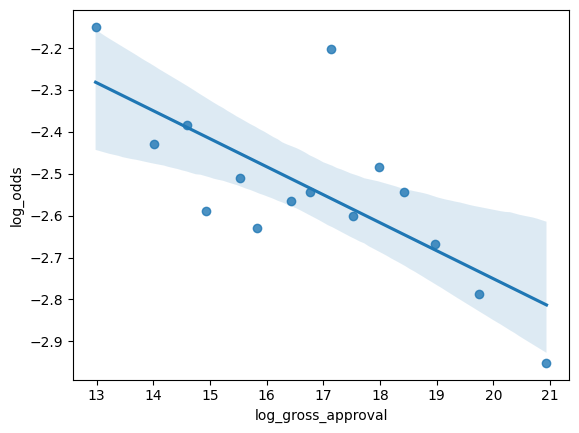

In [ ]:
# Determine 

sns.regplot(data = loan_size_check, x = 'log_gross_approval', y = 'log_odds')
plt.show()

Empirical logit check for log_gross_approval shows a generally linear trend with no systematic curvature, supporting the decision to use the feature log-transformed rather than binned or polynomial. The trend is negative, in line with EDA expectations. This graph uses the actual outcomes in the training data rather than the output of the fitted model, so other features are not being held constant.

In [21]:
def var_names(col):
    return (col
    .str.replace('C(naics_sector_description, Treatment(reference="Construction"))[T.', "")
    .str.replace('C(term_bin, Treatment(reference="61-84mo"))[T.', "")
    .str.replace('revolver_status[T.True]', 'revolver_status')
    .str.replace(']', "")
    )

X_vif = pd.DataFrame()
X_vif["Variables"] = default_rate_mdl.model.exog_names
X_vif['VIF'] = np.round([variance_inflation_factor(default_rate_mdl.model.exog, i) for i in range(X_vif.shape[0])], 2)
X_vif['Variables'] = var_names(X_vif['Variables'])
X_vif.sort_values(by = 'VIF', ascending = False)

,Variables,VIF
0,Intercept,118.75
16,Retail Trade,2.05
25,log_gross_approval,2.02
1,Accommodation and Food Services,2.00
23,241-324mo,1.92
24,85-120mo,1.87
13,"Professional, Scientific, and Technical Services",1.78
20,revolver_status,1.76
7,Health Care and Social Assistance,1.76
12,Other Services (except Public Administration),1.71


### Log Gross Approval

Interestingly, log_gross_approval's coefficient of 0.11 indicates the odds of default increases by 11% for every doubling in loan size, which goes against what we found during EDA. In EDA, we found the opposite effect; default rate decreases as loan size increases. The standard error of 0.005 is very small compared to the coefficient, and the z-score of 21 indicates the effect on default is statistically significant.

Term appears to be correlated with loan size according to term_size_comparison in the EDA notebook. Term bin default rates decrease as the term increases in length, and loan size generally increases with term length. However, since term and the other features are being held constant in the model, the coefficient only reflects loan size without any influence from term. Term confounding with loan size could be the reason why default rates appeared to decrease as loan size increased in EDA.

### Revolver Status

Loans with revolving terms carry lower risk than non-revolvers with a relatively small standard error. Z-score of -8.224 indicates this is significant.

### Term Bins

In line with what we discovered in EDA, the coefficient for the 0-60mo bucket is incredibly high at 1.81. The standard error of 0.02 is quite low and the z-score of 88 indicates strong significance. Short-term loans appear to have a large magnitude of effect on default, greatly increasing the risk.

By contrast, the 241-324mo bin carries a lower risk of default with a coefficient of -1.24. Z-score is -23. This bin covers many real estate loans including those that are extended for construction purposes.

Unexpectedly, the 85-120mo bin has a higher risk of default compared to our reference, 61-84mo.

### NAICS Sectors

Retail's coefficient suggests an increased risk of default compared to our reference, Construction, with all else equal. Its z-score (9.2) indicates significance.

In the Mean Approval and Default Rate by NAICS Sector graph in the EDA notebook, Education and Other Services showed lower risks of default than Construction. However, their coefficients suggest they have higher risks when all else is equal. Their standard errors are both relatively high, and their z-scores indicate significance. The sample size for Other is over 30k while Education is around 4.6k.

Construction's default rate of 7.78% is near the portfolio mean of 7.54%, but when all other features are matched as they are in the model, most sectors show lower odds of default than Construction. This suggests Construction, with all other features held constant, displays modestly above-average risk.

- When pulling the proportions of loans per term bin for each sector, we see that Construction has about 27% in the highest risk bin, 0-60mo. This is about 5% higher than the average proportion across the whole portfolio, 22%. VIF will indicate whether the overlap between term and sector is inflating standard errors.

### Collateral Indicator

Secured loans (collateral indicator = 1) have a coefficient of -0.42 with a z-score of -24, indicating secured loans have a significantly lower risk of default compared to unsecured loans.

### VIF
No signficant VIFs were reported. Most remained under 2, well below the threshold of 5 or even 2.5. 
Ultimately, there is no indication that predictor overlap is inflating standard errors (no evidence of multicollinerality).
Retail happens to have the largest VIF, which is interesting considering its high default rate.
The intercept's VIF is not applicable.